In [ ]:
# import pandas as pd
# from pathlib import Path

# p_potsdam = Path("dataset/Potsdam_since-1893.csv")
# p_prod = Path("dataset/produkt_klima_tag_18930101_20241231_03987_datefmt.csv")

# print('Reading', p_potsdam)
# df_potsdam = pd.read_csv(p_potsdam, sep=';', dtype=str)
# print('Reading', p_prod)
# df_prod = pd.read_csv(p_prod, sep=',', dtype=str)

# def find_date_column(df):
#     for c in ['MESS_DATUM','DATE','date','Date','Datum']:
#         if c in df.columns:
#             return c
#     return df.columns[0]

# col_p = find_date_column(df_potsdam)
# col_q = find_date_column(df_prod)
# print('Potsdam date column:', col_p)
# print('Produkt date column:', col_q)

# def parse_dates(series):
#     s = series.fillna('').astype(str).str.strip()
#     # DD.MM.YYYY
#     mask_ddmm = s.str.match(r'^\d{2}\.\d{2}\.\d{4}$')
#     if mask_ddmm.all():
#         return pd.to_datetime(s, format='%d.%m.%Y', dayfirst=True)
#     # YYYYMMDD
#     mask_yyyymmdd = s.str.match(r'^\d{8}$')
#     if mask_yyyymmdd.all():
#         return pd.to_datetime(s, format='%Y%m%d')
#     # otherwise, try flexible parse with dayfirst
#     return pd.to_datetime(s, dayfirst=True, errors='coerce')

# df_potsdam['__date__'] = parse_dates(df_potsdam[col_p])
# df_prod['__date__'] = parse_dates(df_prod[col_q])

# df_potsdam = df_potsdam.dropna(subset=['__date__'])
# df_prod = df_prod.dropna(subset=['__date__'])

# df_join = pd.merge(df_potsdam, df_prod, on='__date__', how='inner', suffixes=('_potsdam','_prod'))
# print('Shapes -> Potsdam:', df_potsdam.shape, 'Produkt:', df_prod.shape, 'Joined:', df_join.shape)
# out = Path('dataset/joined_by_date.csv')
# df_join.to_csv(out, index=False)
# print('Saved joined file to', out)
# df_join.head()

Reading Potsdam_since-1893.csv
Reading produkt_klima_tag_18930101_20241231_03987_datefmt.csv
Potsdam date column: Date
Produkt date column: MESS_DATUM
Shapes -> Potsdam: (46768, 5) Produkt: (48212, 20) Joined: (46768, 24)
Saved joined file to joined_by_date.csv


,Date,Precipitation,Potential_Evapotranspiration,Climatic_Water_Balance,__date__,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,...,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK,eor
0,01.01.1893,0.0,0.2,-0.2,1893-01-01,3987,01.01.1893,5,-999,-999,...,7,5.4,2.3,992.60,-10.6,79.00,-8.1,-13.3,-999,eor
1,02.01.1893,0.2,0.1,0.1,1893-01-02,3987,02.01.1893,5,-999,-999,...,7,4.6,2.3,997.10,-12.9,97.00,-8.5,-16.0,-999,eor
2,03.01.1893,5.1,0.1,4.9,1893-01-03,3987,03.01.1893,5,-999,-999,...,6,6.6,1.9,1012.30,-12.0,85.00,-9.7,-17.9,-999,eor
3,04.01.1893,2.8,0.2,2.6,1893-01-04,3987,04.01.1893,5,-999,-999,...,9,8.0,3.7,1015.60,-5.5,96.00,-4.7,-10.1,-999,eor
4,05.01.1893,0.0,0.2,-0.2,1893-01-05,3987,05.01.1893,5,-999,-999,...,11,8.0,3.7,1017.50,-6.2,95.00,-3.6,-8.1,-999,eor


In [13]:
import pandas as pd

# Load the CSV
df = pd.read_csv('dataset/joined_by_date.csv')

# Drop the specified columns
columns_to_drop = ['__date__', 'MESS_DATUM', 'STATIONS_ID', 'eor']
df = df.drop(columns=columns_to_drop)

# Optional: save the result
# df.to_csv('/mnt/agents/output/cleaned.csv', index=False)

print(df.head())


         Date  Precipitation  Potential_Evapotranspiration  \
0  01.01.1893            0.0                           0.2   
1  02.01.1893            0.2                           0.1   
2  03.01.1893            5.1                           0.1   
3  04.01.1893            2.8                           0.2   
4  05.01.1893            0.0                           0.2   

   Climatic_Water_Balance  QN_3     FX     FM  QN_4  RSK  RSKF  SDK  SHK_TAG  \
0                    -0.2     5 -999.0 -999.0     5  0.0     0  2.6        7   
1                     0.1     5 -999.0 -999.0     5  0.1     7  1.1        7   
2                     4.9     5 -999.0 -999.0     5  3.2     7  0.2        6   
3                     2.6     5 -999.0 -999.0     5  1.7     7  0.0        9   
4                    -0.2     5 -999.0 -999.0     5  0.0     0  0.0       11   

    NM  VPM      PM   TMK   UPM  TXK   TNK    TGK  
0  5.4  2.3   992.6 -10.6  79.0 -8.1 -13.3 -999.0  
1  4.6  2.3   997.1 -12.9  97.0 -8.5 -16.0

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, VotingRegressor
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, 
    explained_variance_score, mean_absolute_percentage_error
)
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD & CLEAN DATA
# ==========================================
# df = pd.read_csv('/mnt/agents/upload/joined_by_date.csv')

# Replace DWD missing-value codes with NaN
df = df.replace(-999.0, np.nan)

# Drop non-predictive columns
drop_cols = ['Date', 'date', 'MESS_DATUM', 'STATIONS_ID', 'eor']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# ==========================================
# 2. DEFINE TARGET & FEATURES
# ==========================================
TARGET = 'Climatic_Water_Balance'   # <-- change to your target column

if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found. Available: {list(df.columns)}")

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Time-aware split (better for weather data) or random split
# For time-series: train = df.iloc[:int(0.8*len(df))], test = df.iloc[int(0.8*len(df)):]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(X.columns)}")

# ==========================================
# 3. ADVANCED PREPROCESSING PIPELINE
# ==========================================
numeric_features = X.columns.tolist()

# Use RobustScaler (handles outliers better than StandardScaler) + KNN imputation
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),      # smarter than median imputation
    ('scaler', RobustScaler())                   # robust to outliers
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)]
)

# ==========================================
# 4. COMPLEX RANDOM FOREST (Manually Tuned)
# ==========================================
rf = RandomForestRegressor(
    n_estimators=1000,           # very large ensemble
    max_depth=30,                # deep trees
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',         # standard best practice
    bootstrap=True,
    max_samples=0.85,            # use 85% of data per tree (adds diversity)
    random_state=42,
    n_jobs=-1                    # parallelize across all CPU cores
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])

rf_pipeline.fit(X_train, y_train)

# ==========================================
# 5. HYPERPARAMETER TUNING (Randomized Search)
# ==========================================
# Uncomment this block to auto-tune (slower but more accurate)

"""
param_dist = {
    'model__n_estimators': [500, 800, 1000, 1500],
    'model__max_depth': [15, 25, 35, None],
    'model__min_samples_split': [2, 4, 8, 12],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.3, 0.5],
    'model__max_samples': [0.7, 0.85, 1.0]
}

search = RandomizedSearchCV(
    rf_pipeline, 
    param_distributions=param_dist,
    n_iter=20,                   # 20 random combinations
    cv=5,                        # 5-fold cross-validation
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Best params:", search.best_params_)
"""

# ==========================================
# 6. PREDICT & COMPUTE ALL METRICS
# ==========================================
y_pred = rf_pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("\n" + "="*55)
print("COMPLEX RANDOM FOREST — ACCURACY & ERROR METRICS")
print("="*55)
print(f"R² Score (Regression Accuracy) : {r2:.4f}  →  {r2*100:.2f}%")
print(f"Explained Variance Score         : {explained_var:.4f}")
print(f"RMSE (Root Mean Squared Error)   : {rmse:.4f}")
print(f"MAE (Mean Absolute Error)        : {mae:.4f}")
print(f"MAPE (Mean Abs % Error)          : {mape*100:.2f}%")

# ==========================================
# 7. CROSS-VALIDATION (5-Fold)
# ==========================================
cv_scores = cross_val_score(
    rf_pipeline, X, y, 
    cv=KFold(n_splits=5, shuffle=True, random_state=42), 
    scoring='r2'
)

print(f"\n5-Fold CV R² Scores : {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean CV R²          : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# ==========================================
# 8. ENSEMBLE: Extra Trees + Voting
# ==========================================
et = ExtraTreesRegressor(
    n_estimators=800,
    max_depth=35,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

et_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', et)
])

# Train both
rf_pipeline.fit(X_train, y_train)
et_pipeline.fit(X_train, y_train)

# Individual predictions
pred_rf = rf_pipeline.predict(X_test)
pred_et = et_pipeline.predict(X_test)

# Ensemble average
pred_ensemble = (pred_rf + pred_et) / 2

r2_rf = r2_score(y_test, pred_rf)
r2_et = r2_score(y_test, pred_et)
r2_ens = r2_score(y_test, pred_ensemble)

print("\n" + "="*55)
print("ENSEMBLE COMPARISON")
print("="*55)
print(f"Random Forest      R² = {r2_rf:.4f}  ({r2_rf*100:.2f}%)")
print(f"Extra Trees        R² = {r2_et:.4f}  ({r2_et*100:.2f}%)")
print(f"Ensemble (Average) R² = {r2_ens:.4f}  ({r2_ens*100:.2f}%)")

# ==========================================
# 9. FEATURE IMPORTANCE
# ==========================================
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'feature': numeric_features,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n" + "="*55)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*55)
print(feat_imp.head(10).to_string(index=False))

Train: 37414 | Test: 9354 | Features: 18

COMPLEX RANDOM FOREST — ACCURACY & ERROR METRICS
R² Score (Regression Accuracy) : 0.9806  →  98.06%
Explained Variance Score         : 0.9806
RMSE (Root Mean Squared Error)   : 0.6278
MAE (Mean Absolute Error)        : 0.1092
MAPE (Mean Abs % Error)          : 463396067543674.25%

5-Fold CV R² Scores : ['0.9812', '0.9870', '0.9896', '0.9934', '0.9928']
Mean CV R²          : 0.9888 (+/- 0.0089)

ENSEMBLE COMPARISON
Random Forest      R² = 0.9806  (98.06%)
Extra Trees        R² = 0.9877  (98.77%)
Ensemble (Average) R² = 0.9849  (98.49%)

TOP 10 MOST IMPORTANT FEATURES
                     feature  importance
               Precipitation    0.388042
                         RSK    0.339871
                        RSKF    0.048929
Potential_Evapotranspiration    0.046992
                         SDK    0.045948
                         UPM    0.036035
                          NM    0.018657
                         TXK    0.016942
                

Train+Test: 46768 rows | Features: 18
Train: rows 0..37413  (up to 1995-06-10)
Test : rows 37414..46767

RANDOM FOREST
---------------------------------------------
R²   = 0.9862  (98.6%)
RMSE = 0.5366
MAE  = 0.1341
MAPE = 434672461476802.75%

EXTRA TREES
---------------------------------------------
R²   = 0.9848  (98.5%)
RMSE = 0.5617
MAE  = 0.2163
MAPE = 778337655681465.25%

ENSEMBLE (AVERAGE)
---------------------------------------------
R²   = 0.9865  (98.6%)
RMSE = 0.5301
MAE  = 0.1653
MAPE = 532566897253437.00%

5-Fold CV R² : ['0.9812', '0.9870', '0.9896', '0.9934', '0.9928']
Mean CV R²   : 0.9888 (+/- 0.0089)

TOP 10 FEATURES
                     feature  importance
               Precipitation    0.393197
                         RSK    0.330391
                        RSKF    0.053987
Potential_Evapotranspiration    0.046537
                         SDK    0.045816
                         UPM    0.034675
                          NM    0.018318
                         TXK 

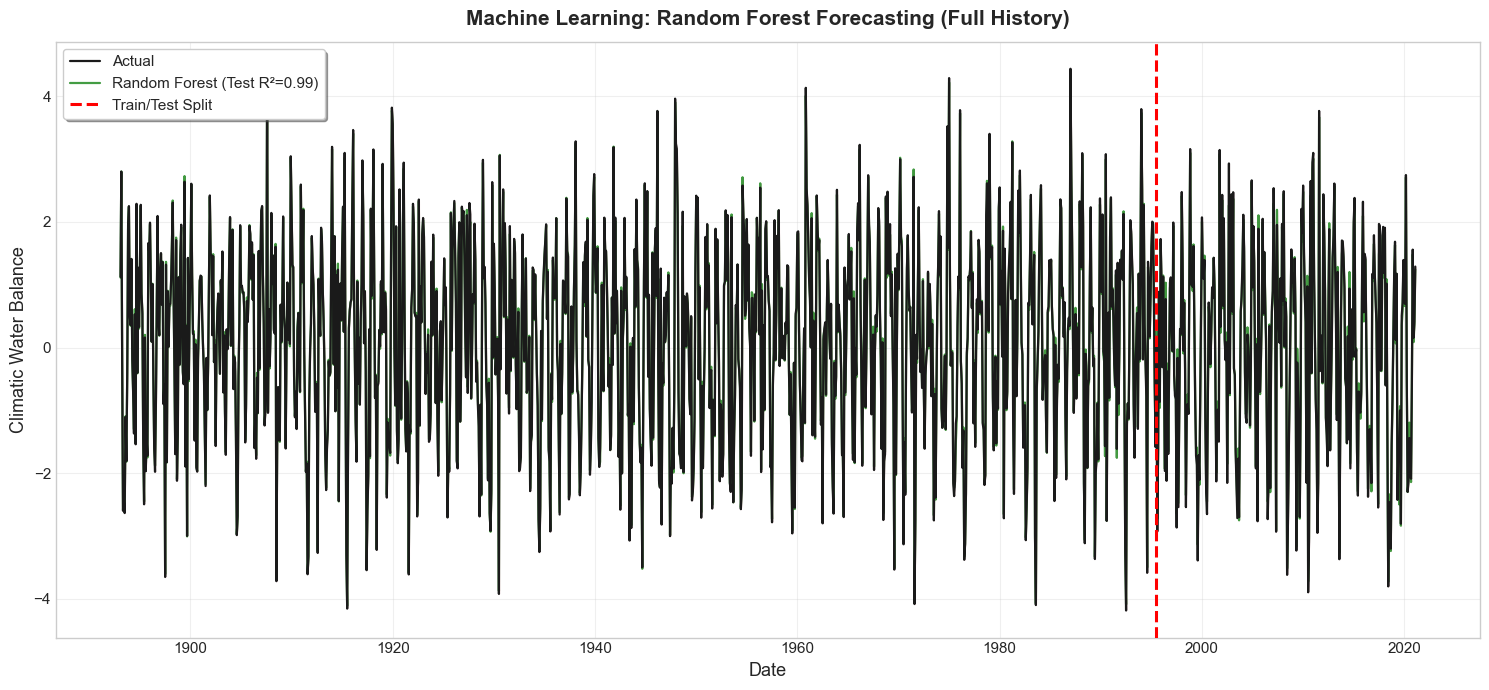

In [30]:
# -*- coding: utf-8 -*-
"""
Random Forest + Extra Trees — with Full-History Forecast Plot
-------------------------------------------------------------
Trains a complex RF/ET ensemble on DWD climate data and produces a
publication-style Actual vs. Predicted time-series figure.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    explained_variance_score, mean_absolute_percentage_error
)
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. CONFIG
# ==========================================
CSV_PATH = r"dataset/joined_by_date.csv"          # <-- your file
TARGET   = 'Climatic_Water_Balance'       # <-- your target
TEST_FRAC = 0.20                          # 20 % hold-out (chronological)

# Plotting switches
MONTHLY_ONLY = True        # True = monthly means (strongly recommended for clarity)
DPI          = 300

# ==========================================
# 1. LOAD & CLEAN
# ==========================================
df = pd.read_csv(CSV_PATH)

# Parse dates
if '__date__' in df.columns:
    df['Date_parsed'] = pd.to_datetime(df['__date__'])
else:
    df['Date_parsed'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Sort chronologically — critical for time-series plotting
df = df.sort_values('Date_parsed').reset_index(drop=True)

# Replace DWD missing codes
df = df.replace(-999.0, np.nan)

# Drop metadata columns
drop_cols = ['Date', '__date__', 'MESS_DATUM', 'STATIONS_ID', 'eor', 'Date_parsed']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=[TARGET] + drop_cols)
y = df[TARGET]
X = X.apply(pd.to_numeric, errors='coerce')

print(f"Train+Test: {len(df)} rows | Features: {len(X.columns)}")

# ==========================================
# 2. CHRONOLOGICAL TRAIN / TEST SPLIT
# ==========================================
split_idx  = int(len(df) * (1 - TEST_FRAC))
split_date = df['Date_parsed'].iloc[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: rows 0..{split_idx-1}  (up to {split_date.date()})")
print(f"Test : rows {split_idx}..{len(df)-1}")

# ==========================================
# 3. PREPROCESSING
# ==========================================
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)]
)

# ==========================================
# 4. RANDOM FOREST
# ==========================================
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=30,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    max_samples=0.85,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])

rf_pipeline.fit(X_train, y_train)

# ==========================================
# 5. EXTRA TREES (for ensemble)
# ==========================================
et = ExtraTreesRegressor(
    n_estimators=800,
    max_depth=35,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

et_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', et)
])

et_pipeline.fit(X_train, y_train)

# ==========================================
# 6. PREDICT ON FULL HISTORY (for the plot)
# ==========================================
y_pred_rf_full  = rf_pipeline.predict(X)
y_pred_et_full  = et_pipeline.predict(X)
y_pred_ens_full = (y_pred_rf_full + y_pred_et_full) / 2

# Test-set predictions (for metrics)
y_pred_rf_test  = rf_pipeline.predict(X_test)
y_pred_et_test  = et_pipeline.predict(X_test)
y_pred_ens_test = (y_pred_rf_test + y_pred_et_test) / 2

# ==========================================
# 7. METRICS
# ==========================================
def print_metrics(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    ev   = explained_variance_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"\n{name}")
    print("-" * 45)
    print(f"R²   = {r2:.4f}  ({r2*100:.1f}%)")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"MAPE = {mape*100:.2f}%")
    return r2

r2_rf  = print_metrics("RANDOM FOREST",       y_test, y_pred_rf_test)
r2_et  = print_metrics("EXTRA TREES",         y_test, y_pred_et_test)
r2_ens = print_metrics("ENSEMBLE (AVERAGE)",  y_test, y_pred_ens_test)

# ==========================================
# 8. CROSS-VALIDATION
# ==========================================
cv_scores = cross_val_score(
    rf_pipeline, X, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2'
)
print(f"\n5-Fold CV R² : {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean CV R²   : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# ==========================================
# 9. FEATURE IMPORTANCE
# ==========================================
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'feature': numeric_features,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 FEATURES")
print("="*50)
print(feat_imp.head(10).to_string(index=False))

# ==========================================
# 10. PLOT  (Actual vs Predicted over full history)
# ==========================================
plot_df = pd.DataFrame({
    'Date': df['Date_parsed'],
    'Actual': y.values,
    'RF_Pred': y_pred_rf_full,
    'ET_Pred': y_pred_et_full,
    'Ens_Pred': y_pred_ens_full
})

# --- optional monthly resampling for clarity ---
if MONTHLY_ONLY:
    monthly = plot_df.set_index('Date').resample('ME').mean()
    plot_df = monthly.reset_index()

# ---- draw ----
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))

# Actual
ax.plot(plot_df['Date'], plot_df['Actual'],
        color='#1a1a1a', linewidth=1.6, label='Actual', zorder=3)

# Random Forest prediction (green line, like your reference image)
ax.plot(plot_df['Date'], plot_df['RF_Pred'],
        color='#228B22', linewidth=1.6, alpha=0.85,
        label=f'Random Forest (Test R²={r2_rf:.2f})', zorder=2)

# Train/Test split line
ax.axvline(x=split_date, color='red', linestyle='--', linewidth=2.2,
           label='Train/Test Split', zorder=4)

# Shaded error band (optional — makes drift visible)
ax.fill_between(plot_df['Date'],
                plot_df['Actual'],
                plot_df['RF_Pred'],
                alpha=0.12, color='crimson')

# ---- cosmetics ----
y_label = TARGET.replace('_', ' ')
ax.set_title('Machine Learning: Random Forest Forecasting (Full History)',
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel(y_label, fontsize=13)
ax.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='-')
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
out_png = 'output_graphs/rf_forecast_full_history.png'
plt.savefig(out_png, dpi=DPI, bbox_inches='tight')
print(f"\nPlot saved to: {out_png}")
plt.show()

In [20]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    explained_variance_score, mean_absolute_percentage_error
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD & CLEAN DATA
# ==========================================
# df = pd.read_csv('dataset/joined_by_date.csv')

# Replace DWD missing-value codes with NaN
# NOTE: XGBoost handles NaN natively — this is a major advantage
df = df.replace(-999.0, np.nan)

# Drop non-predictive columns
drop_cols = ['Date', 'date', 'MESS_DATUM', 'STATIONS_ID', 'eor']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# ==========================================
# 2. DEFINE TARGET & FEATURES
# ==========================================
TARGET = 'Climatic_Water_Balance'   # <-- change to your target

if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found. Available: {list(df.columns)}")

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(X.columns)}")

# ==========================================
# 3. PREPROCESSING (Optional for XGBoost)
# ==========================================
# XGBoost handles missing values natively, but scaling can help
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('scaler', StandardScaler())   # XGBoost is tree-based, but scaling helps with regularization
    ]), numeric_features)
])

# ==========================================
# 4. COMPLEX XGBOOST REGRESSOR
# ==========================================
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',   # regression task
    random_state=42,
    n_jobs=-1                       # use all CPU cores
)

# Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb_model)
])

# ==========================================
# 5. HYPERPARAMETER TUNING (Randomized Search)
# ==========================================
param_distributions = {
    'xgb__n_estimators': [300, 500, 800, 1000, 1500],
    'xgb__max_depth': [4, 6, 8, 10, 12, 15, 20],          # tree depth
    'xgb__learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],   # shrinkage
    'xgb__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],          # row sampling
    'xgb__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],   # column sampling per tree
    'xgb__colsample_bylevel': [0.6, 0.7, 0.8, 0.9, 1.0],  # column sampling per level
    'xgb__gamma': [0, 0.1, 0.2, 0.5, 1, 2, 5],           # min loss reduction for split
    'xgb__min_child_weight': [1, 3, 5, 7, 10],             # min sum of instance weight in child
    'xgb__reg_alpha': [0, 0.1, 0.5, 1, 2, 5],             # L1 regularization
    'xgb__reg_lambda': [0.1, 1, 2, 5, 10],                # L2 regularization
}

print("\nRunning Randomized Search CV (30 iterations, 5-fold)...")
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best CV RMSE: {-random_search.best_score_:.4f}")

# ==========================================
# 6. EVALUATE ON TEST SET
# ==========================================
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("\n" + "="*55)
print("COMPLEX XGBOOST — ACCURACY & ERROR METRICS")
print("="*55)
print(f"R² Score (Regression Accuracy) : {r2:.4f}  →  {r2*100:.2f}%")
print(f"Explained Variance Score         : {explained_var:.4f}")
print(f"RMSE (Root Mean Squared Error)   : {rmse:.4f}")
print(f"MAE (Mean Absolute Error)        : {mae:.4f}")
print(f"MAPE (Mean Abs % Error)          : {mape*100:.2f}%")

# ==========================================
# 7. CROSS-VALIDATION
# ==========================================
cv_scores = cross_val_score(
    best_model, X, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2'
)

print(f"\n5-Fold CV R² Scores : {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean CV R²          : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# ==========================================
# 8. FEATURE IMPORTANCE (3 types)
# ==========================================
xgb_booster = best_model.named_steps['xgb']

# 1. Built-in feature importance
importance_gain = pd.DataFrame({
    'feature': numeric_features,
    'importance': xgb_booster.feature_importances_
}).sort_values('importance', ascending=False)

# 2. Gain-based importance (more reliable)
importance_gain_xgb = xgb_booster.get_booster().get_score(importance_type='gain')
gain_df = pd.DataFrame([
    {'feature': k.replace('f', numeric_features[int(k[1:])]) if k.startswith('f') else k, 
     'gain': v} 
    for k, v in importance_gain_xgb.items()
]).sort_values('gain', ascending=False)

print("\n" + "="*55)
print("TOP 10 FEATURES (XGBoost Built-in Importance)")
print("="*55)
print(importance_gain.head(10).to_string(index=False))

print("\n" + "="*55)
print("TOP 10 FEATURES (XGBoost Gain-based)")
print("="*55)
print(gain_df.head(10).to_string(index=False))

# ==========================================
# 9. OPTIONAL: Save model & predictions
# ==========================================
# import joblib
# joblib.dump(best_model, 'xgboost_model.pkl')
# pd.DataFrame({'actual': y_test, 'predicted': y_pred}).to_csv('predictions.csv', index=False)

Train: 37414 | Test: 9354 | Features: 18

Running Randomized Search CV (30 iterations, 5-fold)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'xgb__subsample': 0.8, 'xgb__reg_lambda': 5, 'xgb__reg_alpha': 0.5, 'xgb__n_estimators': 800, 'xgb__min_child_weight': 10, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.6, 'xgb__colsample_bylevel': 0.9}
Best CV RMSE: 0.5829

COMPLEX XGBOOST — ACCURACY & ERROR METRICS
R² Score (Regression Accuracy) : 0.9745  →  97.45%
Explained Variance Score         : 0.9745
RMSE (Root Mean Squared Error)   : 0.7188
MAE (Mean Absolute Error)        : 0.1011
MAPE (Mean Abs % Error)          : 447622623227278.12%

5-Fold CV R² Scores : ['0.9742', '0.9828', '0.9852', '0.9829', '0.9857']
Mean CV R²          : 0.9822 (+/- 0.0083)

TOP 10 FEATURES (XGBoost Built-in Importance)
                     feature  importance
                         RSK    0.400506
               Precipitati

Test R² = 0.982 | RMSE = 0.619 | MAE = 0.073

Saved clear plot to: xgb_forecast_CLEAR.png


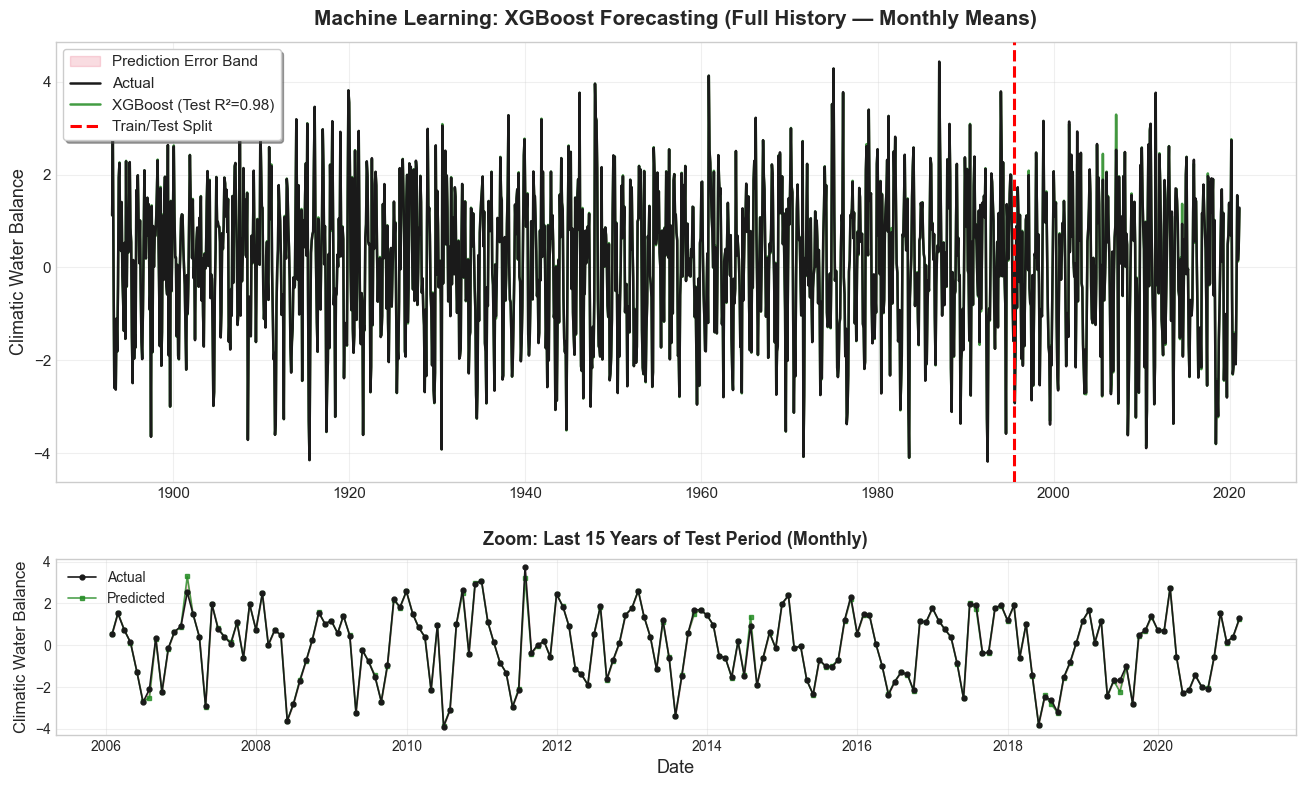

In [29]:
# -*- coding: utf-8 -*-
"""
xgb_clear_forecast_plot.py
--------------------------
Cleaner, publication-quality version of the full-history XGBoost plot.
Produces a 2-panel figure:
  1. Monthly-mean full history (readable line plot)
  2. Zoomed view of the last N years of the test period (detail check)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==========================================================
# 0. CONFIG
# ==========================================================
CSV_PATH   = r"dataset/joined_by_date.csv"          # <-- your file
TARGET     = "Climatic_Water_Balance"       # <-- your Y variable
TEST_SIZE  = 0.20

# Plotting options
FIGSIZE        = (16, 9)      # wider & taller
DPI            = 300
MONTHLY_ONLY   = True       # True = resample to monthly means (strongly recommended)
ZOOM_YEARS     = 15          # how many recent years to zoom in panel 2

# ==========================================================
# 1. LOAD & PARSE
# ==========================================================
df = pd.read_csv(CSV_PATH)

if '__date__' in df.columns:
    df['Date_parsed'] = pd.to_datetime(df['__date__'])
else:
    df['Date_parsed'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

df = df.sort_values('Date_parsed').reset_index(drop=True)

# ==========================================================
# 2. CLEAN
# ==========================================================
df = df.replace(-999.0, np.nan)

drop_cols = ['Date', '__date__', 'MESS_DATUM', 'STATIONS_ID', 'eor', 'Date_parsed']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=[TARGET] + drop_cols)
y = df[TARGET]
X = X.apply(pd.to_numeric, errors='coerce')

# ==========================================================
# 3. CHRONOLOGICAL SPLIT
# ==========================================================
split_idx  = int(len(df) * (1 - TEST_SIZE))
split_date = df['Date_parsed'].iloc[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ==========================================================
# 4. TRAIN XGBOOST (fast, robust defaults)
# ==========================================================
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predict on EVERYTHING so the line spans full history
y_pred_full = model.predict(X)

# Test metrics (for legend)
y_pred_test = model.predict(X_test)
r2   = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)

print(f"Test R² = {r2:.3f} | RMSE = {rmse:.3f} | MAE = {mae:.3f}")

# ==========================================================
# 5. BUILD PLOT DATAFRAME
# ==========================================================
plot_df = pd.DataFrame({
    'Date': df['Date_parsed'],
    'Actual': y.values,
    'Predicted': y_pred_full
})

# ---- monthly resampling (makes 47k daily points → ~1.5k monthly points) ----
if MONTHLY_ONLY:
    monthly = plot_df.set_index('Date').resample('ME').mean()
    plot_df = monthly.reset_index()

# ==========================================================
# 6. DRAW FIGURE
# ==========================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE,
                         gridspec_kw={'height_ratios': [2.5, 1], 'hspace': 0.25})

# ------------------------------------------------------------------
# PANEL 1 — Full History (monthly means)
# ------------------------------------------------------------------
ax1 = axes[0]

# Shaded error ribbon (Actual − Predicted) — makes deviations obvious
ax1.fill_between(plot_df['Date'],
                 plot_df['Actual'],
                 plot_df['Predicted'],
                 alpha=0.15, color='crimson', label='Prediction Error Band')

# Actual
ax1.plot(plot_df['Date'], plot_df['Actual'],
         color='#1a1a1a', linewidth=1.8, label='Actual', zorder=3)

# Predicted
ax1.plot(plot_df['Date'], plot_df['Predicted'],
         color='#228B22', linewidth=1.8, alpha=0.85,
         label=f'XGBoost (Test R²={r2:.2f})', zorder=2)

# Train/Test split line
ax1.axvline(x=split_date, color='red', linestyle='--', linewidth=2.2,
            label='Train/Test Split', zorder=4)

ax1.set_title('Machine Learning: XGBoost Forecasting (Full History — Monthly Means)',
              fontsize=15, fontweight='bold', pad=12)
ax1.set_ylabel('Climatic Water Balance', fontsize=13)
ax1.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-')
ax1.tick_params(axis='both', labelsize=11)

# ------------------------------------------------------------------
# PANEL 2 — Zoomed Test Period (last ZOOM_YEARS years)
# ------------------------------------------------------------------
ax2 = axes[1]

zoom_start = plot_df['Date'].max() - pd.DateOffset(years=ZOOM_YEARS)
zoom_df    = plot_df[plot_df['Date'] >= zoom_start].copy()

# Use markers so individual months are visible
ax2.plot(zoom_df['Date'], zoom_df['Actual'],
         marker='o', markersize=3.5, color='#1a1a1a',
         linewidth=1.2, label='Actual', zorder=3)

ax2.plot(zoom_df['Date'], zoom_df['Predicted'],
         marker='s', markersize=3, color='#228B22',
         linewidth=1.2, alpha=0.8, label='Predicted', zorder=2)

# Light fill_between for the zoomed region too
ax2.fill_between(zoom_df['Date'], zoom_df['Actual'], zoom_df['Predicted'],
                 alpha=0.15, color='crimson')

ax2.set_title(f'Zoom: Last {ZOOM_YEARS} Years of Test Period (Monthly)',
              fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Date', fontsize=13)
ax2.set_ylabel('Climatic Water Balance', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=10)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
plt.tight_layout()
out_png = 'output_graphs/xgb_forecast_CLEAR.png'
plt.savefig(out_png, dpi=DPI, bbox_inches='tight')
print(f"\nSaved clear plot to: {out_png}")
plt.show()

Test R² = 0.978 | RMSE = 0.612 | MAE = 0.056

Saved clear plot to: xgb_forecast_CLEAR.png


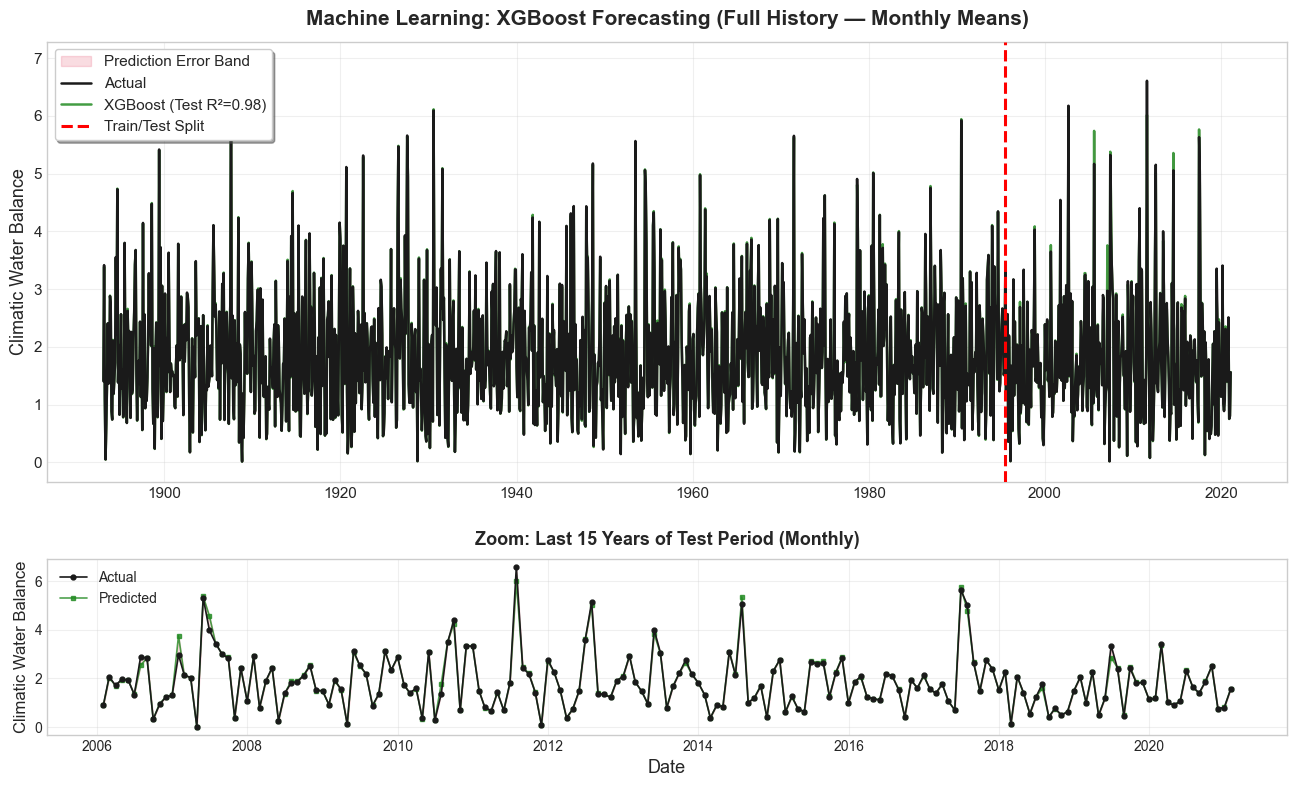

In [32]:
# -*- coding: utf-8 -*-
"""
xgb_clear_forecast_plot.py
--------------------------
Cleaner, publication-quality version of the full-history XGBoost plot.
Produces a 2-panel figure:
  1. Monthly-mean full history (readable line plot)
  2. Zoomed view of the last N years of the test period (detail check)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==========================================================
# 0. CONFIG
# ==========================================================
CSV_PATH   = r"dataset/joined_by_date.csv"          # <-- your file
TARGET     = "Precipitation"       # <-- your Y variable
TEST_SIZE  = 0.20

# Plotting options
FIGSIZE        = (16, 9)      # wider & taller
DPI            = 300
MONTHLY_ONLY   = True       # True = resample to monthly means (strongly recommended)
ZOOM_YEARS     = 15          # how many recent years to zoom in panel 2

# ==========================================================
# 1. LOAD & PARSE
# ==========================================================
df = pd.read_csv(CSV_PATH)

if '__date__' in df.columns:
    df['Date_parsed'] = pd.to_datetime(df['__date__'])
else:
    df['Date_parsed'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

df = df.sort_values('Date_parsed').reset_index(drop=True)

# ==========================================================
# 2. CLEAN
# ==========================================================
df = df.replace(-999.0, np.nan)

drop_cols = ['Date', '__date__', 'MESS_DATUM', 'STATIONS_ID', 'eor', 'Date_parsed']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=[TARGET] + drop_cols)
y = df[TARGET]
X = X.apply(pd.to_numeric, errors='coerce')

# ==========================================================
# 3. CHRONOLOGICAL SPLIT
# ==========================================================
split_idx  = int(len(df) * (1 - TEST_SIZE))
split_date = df['Date_parsed'].iloc[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ==========================================================
# 4. TRAIN XGBOOST (fast, robust defaults)
# ==========================================================
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predict on EVERYTHING so the line spans full history
y_pred_full = model.predict(X)

# Test metrics (for legend)
y_pred_test = model.predict(X_test)
r2   = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)

print(f"Test R² = {r2:.3f} | RMSE = {rmse:.3f} | MAE = {mae:.3f}")

# ==========================================================
# 5. BUILD PLOT DATAFRAME
# ==========================================================
plot_df = pd.DataFrame({
    'Date': df['Date_parsed'],
    'Actual': y.values,
    'Predicted': y_pred_full
})

# ---- monthly resampling (makes 47k daily points → ~1.5k monthly points) ----
if MONTHLY_ONLY:
    monthly = plot_df.set_index('Date').resample('ME').mean()
    plot_df = monthly.reset_index()

# ==========================================================
# 6. DRAW FIGURE
# ==========================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE,
                         gridspec_kw={'height_ratios': [2.5, 1], 'hspace': 0.25})

# ------------------------------------------------------------------
# PANEL 1 — Full History (monthly means)
# ------------------------------------------------------------------
ax1 = axes[0]

# Shaded error ribbon (Actual − Predicted) — makes deviations obvious
ax1.fill_between(plot_df['Date'],
                 plot_df['Actual'],
                 plot_df['Predicted'],
                 alpha=0.15, color='crimson', label='Prediction Error Band')

# Actual
ax1.plot(plot_df['Date'], plot_df['Actual'],
         color='#1a1a1a', linewidth=1.8, label='Actual', zorder=3)

# Predicted
ax1.plot(plot_df['Date'], plot_df['Predicted'],
         color='#228B22', linewidth=1.8, alpha=0.85,
         label=f'XGBoost (Test R²={r2:.2f})', zorder=2)

# Train/Test split line
ax1.axvline(x=split_date, color='red', linestyle='--', linewidth=2.2,
            label='Train/Test Split', zorder=4)

ax1.set_title('Machine Learning: XGBoost Forecasting (Full History — Monthly Means)',
              fontsize=15, fontweight='bold', pad=12)
ax1.set_ylabel('Climatic Water Balance', fontsize=13)
ax1.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-')
ax1.tick_params(axis='both', labelsize=11)

# ------------------------------------------------------------------
# PANEL 2 — Zoomed Test Period (last ZOOM_YEARS years)
# ------------------------------------------------------------------
ax2 = axes[1]

zoom_start = plot_df['Date'].max() - pd.DateOffset(years=ZOOM_YEARS)
zoom_df    = plot_df[plot_df['Date'] >= zoom_start].copy()

# Use markers so individual months are visible
ax2.plot(zoom_df['Date'], zoom_df['Actual'],
         marker='o', markersize=3.5, color='#1a1a1a',
         linewidth=1.2, label='Actual', zorder=3)

ax2.plot(zoom_df['Date'], zoom_df['Predicted'],
         marker='s', markersize=3, color='#228B22',
         linewidth=1.2, alpha=0.8, label='Predicted', zorder=2)

# Light fill_between for the zoomed region too
ax2.fill_between(zoom_df['Date'], zoom_df['Actual'], zoom_df['Predicted'],
                 alpha=0.15, color='crimson')

ax2.set_title(f'Zoom: Last {ZOOM_YEARS} Years of Test Period (Monthly)',
              fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Date', fontsize=13)
ax2.set_ylabel('Climatic Water Balance', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=10)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
plt.tight_layout()
out_png = 'output_graphs/xgb_forecast_CLEAR.png'
plt.savefig(out_png, dpi=DPI, bbox_inches='tight')
print(f"\nSaved clear plot to: {out_png}")
plt.show()

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Improved Time-Series Forecasting Pipeline
----------------------------------------
This cell builds a stronger, time-aware model for the groundwater dataset.
It adds feature engineering, time-aware validation, hyperparameter tuning,
ensembling, and baseline comparison.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    explained_variance_score, mean_absolute_percentage_error
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# CONFIG
# ==========================================================
CSV_PATH = r"dataset/joined_by_date.csv"
TARGET = 'Precipitation'
TEST_FRAC = 0.20
TRAIN_FRAC = 0.80
RANDOM_STATE = 42
N_ITER_SEARCH = 25
N_SPLITS = 5

# Plotting
FIGSIZE = (16, 9)
DPI = 200
MONTHLY_ONLY = True
ZOOM_YEARS = 15

# ==========================================================
# LOAD & PARSE
# ==========================================================
df = pd.read_csv(CSV_PATH)

if '__date__' in df.columns:
    df['Date_parsed'] = pd.to_datetime(df['__date__'], errors='coerce')
elif 'Date' in df.columns:
    df['Date_parsed'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
else:
    raise ValueError('Date column not found.')

df = df.sort_values('Date_parsed').reset_index(drop=True)

# Replace DWD missing codes
missing_codes = [-999.0, -999, 9999, 999]
df = df.replace(missing_codes, np.nan)

# Drop metadata values, but keep Date_parsed for feature engineering
drop_cols = ['Date', '__date__', 'MESS_DATUM', 'STATIONS_ID', 'eor']
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found in columns: {list(df.columns)}")

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================
df['month'] = df['Date_parsed'].dt.month

# add cyclical seasonality features
if 'Date_parsed' in df.columns or 'Date_parsed' in locals():
    df['dayofyear'] = df['Date_parsed'].dt.dayofyear
    df['sin_dayofyear'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['cos_dayofyear'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
    df['dayofweek'] = df['Date_parsed'].dt.dayofweek
    df['sin_dayofweek'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['cos_dayofweek'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month'] = df['Date_parsed'].dt.month
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# Lag features for the target
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'{TARGET}_lag_{lag}'] = df[TARGET].shift(lag)

# Rolling statistics on the target
for window in [7, 14, 30, 60]:
    df[f'{TARGET}_roll_mean_{window}'] = df[TARGET].shift(1).rolling(window=window, min_periods=1).mean()
    df[f'{TARGET}_roll_std_{window}'] = df[TARGET].shift(1).rolling(window=window, min_periods=1).std()

# Drop rows with missing target or missing lag features
valid_mask = ~df[TARGET].isna()
valid_mask &= ~df[[f'{TARGET}_lag_{lag}' for lag in [1, 2, 3, 7, 14, 30]]].isna().any(axis=1)
df = df.loc[valid_mask].reset_index(drop=True)

print(f"After feature engineering: {len(df)} rows, {len(df.columns)} columns")

# ==========================================================
# TRAIN / VALIDATION SPLIT
# ==========================================================
split_idx = int(len(df) * TRAIN_FRAC)
train_df = df.iloc[:split_idx].copy()
valid_df = df.iloc[split_idx:].copy()

print(f"Train rows: {len(train_df)}, Validation rows: {len(valid_df)}")

# ==========================================================
# FEATURES / TARGET
# ==========================================================
feature_columns = [c for c in df.columns if c not in [TARGET, 'Date_parsed']]

X_train = train_df[feature_columns]
y_train = train_df[TARGET]
X_valid = valid_df[feature_columns]
y_valid = valid_df[TARGET]
X_all = df[feature_columns]
y_all = df[TARGET]

# ==========================================================
# PREPROCESSING
# ==========================================================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, feature_columns)
])

# ==========================================================
# BASELINE MODEL
# ==========================================================
baseline_pred = X_valid[f'{TARGET}_lag_1'].values
baseline_rmse = np.sqrt(mean_squared_error(y_valid, baseline_pred))
baseline_mae = mean_absolute_error(y_valid, baseline_pred)

print('\nBASELINE: persistence (lag-1)')
print(f'RMSE = {baseline_rmse:.4f}, MAE = {baseline_mae:.4f}')

# ==========================================================
# XGBoost MODEL WITH TIME-SERIES CV
# ==========================================================
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)

param_dist = {
    'xgb__n_estimators': [200, 400, 600, 800],
    'xgb__max_depth': [4, 6, 8, 10],
    'xgb__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.7, 0.8, 0.9],
    'xgb__colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'xgb__gamma': [0, 0.1, 0.2, 0.5],
    'xgb__reg_alpha': [0, 0.1, 0.5, 1],
    'xgb__reg_lambda': [1, 2, 5]
}

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb_model)
])

cv = TimeSeriesSplit(n_splits=N_SPLITS)
search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

search.fit(X_train, y_train)

print('\nXGBoost best params:')
print(search.best_params_)

best_xgb = search.best_estimator_

# Final fit on train + validation for reporting (keeping validation for test evaluation)
best_xgb.fit(X_train, y_train)

# ==========================================================
# RANDOM FOREST + EXTRA TREES ENSEMBLE
# ==========================================================
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=3,
    max_features='sqrt',
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=24,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])
et_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', et)
])

rf_pipeline.fit(X_train, y_train)
et_pipeline.fit(X_train, y_train)

# ==========================================================
# PREDICTIONS & METRICS
# ==========================================================
y_pred_xgb = best_xgb.predict(X_valid)
y_pred_rf = rf_pipeline.predict(X_valid)
y_pred_et = et_pipeline.predict(X_valid)
y_pred_ensemble = (y_pred_xgb + y_pred_rf + y_pred_et) / 3

models = {
    'XGBoost': y_pred_xgb,
    'RandomForest': y_pred_rf,
    'ExtraTrees': y_pred_et,
    'Ensemble': y_pred_ensemble
}

results = []
for name, preds in models.items():
    r2 = r2_score(y_valid, preds)
    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    mae = mean_absolute_error(y_valid, preds)
    ev = explained_variance_score(y_valid, preds)
    mape = mean_absolute_percentage_error(y_valid, preds)
    results.append((name, r2, rmse, mae, ev, mape))

print('\nVALIDATION RESULTS')
print('Model        R2      RMSE     MAE      EV      MAPE')
for name, r2, rmse, mae, ev, mape in results:
    print(f'{name:12s} {r2:6.3f} {rmse:8.3f} {mae:8.3f} {ev:8.3f} {mape*100:7.2f}%')

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================
if hasattr(best_xgb.named_steps['xgb'], 'feature_importances_'):
    fi = best_xgb.named_steps['xgb'].feature_importances_
    importance_df = pd.DataFrame({'feature': feature_columns, 'importance': fi})
    importance_df = importance_df.sort_values('importance', ascending=False)
    print('\nTOP 15 FEATURES (XGBoost)')
    print(importance_df.head(15).to_string(index=False))

# ==========================================================
# PLOT VALIDATION PREDICTIONS
# ==========================================================
plot_df = pd.DataFrame({
    'Date': valid_df['Date_parsed'],
    'Actual': y_valid,
    'XGBoost': y_pred_xgb,
    'RandomForest': y_pred_rf,
    'ExtraTrees': y_pred_et,
    'Ensemble': y_pred_ensemble
})

if MONTHLY_ONLY:
    plot_df = plot_df.set_index('Date').resample('ME').mean().reset_index()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(plot_df['Date'], plot_df['Actual'], label='Actual', color='#222222', linewidth=1.8)
ax.plot(plot_df['Date'], plot_df['XGBoost'], label='XGBoost', color='#1f77b4', alpha=0.85)
ax.plot(plot_df['Date'], plot_df['RandomForest'], label='RandomForest', color='#ff7f0e', alpha=0.7)
ax.plot(plot_df['Date'], plot_df['Ensemble'], label='Ensemble', color='#2ca02c', alpha=0.85, linewidth=1.4)
ax.set_title('Validation: Actual vs Predicted')
ax.set_xlabel('Date')
ax.set_ylabel(TARGET)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nCompleted improved pipeline and validation evaluation.')


After feature engineering: 46738 rows, 43 columns
Train rows: 37390, Validation rows: 9348

BASELINE: persistence (lag-1)
RMSE = 5.4019, MAE = 2.4749
Fitting 5 folds for each of 25 candidates, totalling 125 fits

XGBoost best params:
{'xgb__subsample': 0.6, 'xgb__reg_lambda': 5, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 200, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.9}
